<a href="https://colab.research.google.com/github/PNehu/GE6146/blob/master/notebooks/Lab0_part4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 0: Using Python in Google Colab

In this lab is a chance for you to practice using Python in Google Colab. Several of the other labs will require you to use Python to download, process, or visualize data, so we will get some practice with that here. In addition, you may need to write or use some basic functions to help you with the processing, so this lab will help you practice that as well.

## Problem 1: Write a basic function in Python

Write a function in Python to compute the two roots of a quadratic equation: $$(-b \pm \sqrt{b^2 - 4ac}) / 2a$$ You can use the the "sqrt" function from the "math" module to compute the square root. Return the positive root first. The "math" module will raise a ValueError if the argument to the sqrt function is negative, so you will need to catch this error if it occurs and print out a suitable message.

Fill in the following code cell to write your function. In the sections below and in the labs to come, there will be areas marked for you to fill in to complete partially-started code. These sections will be denoted using three hash symbols: '###' to mark the beginning and end of where you need to add or change the code.

In [48]:
# To make this function work, assume that a, b, and c already exist *outside* the function.
# You simply need to type out the math shown above for each root
import math
def solve_quadratic(a, b, c):
    # Your code below - note that it might be easiest to break the solution up
    # into several lines!
    ### <-- This marks the beginning of where you need to change
    try:
        discriminant = b**2 - 4*a*c
        sqrt_disc = math.sqrt(discriminant)
        root1 = (-b + sqrt_disc) / (2 * a)
        root2 = (-b - sqrt_disc) / (2 * a)
    except ValueError:
        print("Complex roots. Discriminant is negative.")
        root1 = None
        root2 = None
    ### <-- This marks the end of where you need to change
    return root1, root2
    print(solve_quadratic(1, -3, 2))  # Example for x^2 - 3x + 2 = 0
# Click the "run" button or hit Shift + Enter to run the cell

### Tests
The following cells are tests. **Do not change them!** Run each of these as you work on your function. These tests show what would be the correct answer for a properly-defined function so you can compare to what your function gives you. If a cell gives a wrong answer or an error message, go back and work on your function until each test passes.

In [49]:
# Test 1
print(solve_quadratic(1, 1, 1)) # This should print your error message

Complex roots. Discriminant is negative.
(None, None)


In [50]:
# Test 2
print(solve_quadratic(1, 1, -1)) # This should print (0.6180, -1.618)

(0.6180339887498949, -1.618033988749895)


In [51]:
# Test 3
print(solve_quadratic(1, -2, 1)) # This should print (1.0, 1.0)

(1.0, 1.0)


## Problem 2: Load a dataset and plot something

The USGS monitors earthquakes in the US and throughout the world. Make sure the "USGS_seismicity.csv" file from the "data" folder in this repository is downloaded to your computer, and then upload it by running the code cell below. If you are running this notebook on your local machine, then you can skip this cell.

In [52]:
'''
If you are running this notebook on your local machine, you'll need to use the native
upload capabilities of your system. On Colab this should work.

Choose the "USGS_seismicity.csv" file from your local filesystem and upload it.
'''
from google.colab import files
uploaded = files.upload()
for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving USGS_seismicity.csv to USGS_seismicity (2).csv
User uploaded file "USGS_seismicity (2).csv" with length 128372 bytes


This dataset is similar to some other datasets that we'll use in this course. To prepare you for those, we will practice some data visualization and analysis here.

Your first job is to load the dataset using Pandas and take a look at it.

In [53]:
import pandas as pd # pandas is the equivalent of a spreadsheet program in Python

In [54]:
# Here, write code to load the .csv file you uploaded above into the dataframe
# You'll need to uncomment the line below starting with "df = ..." and substitute the name of your file for "filename"
###
df = pd.read_csv('USGS_seismicity (1).csv')
df.head(20) # try changing the number of rows that is displayed. Simply pass a number as an argument to "head": df.head(20)
###

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2021-05-12T15:40:22.770Z,36.538333,-89.595500,8.81,2.98,md,68.0,28.0,0.03659,0.14,...,2021-05-18T22:24:03.710Z,"2 km NE of Marston, Missouri",earthquake,0.13,0.28,0.103,57.0,reviewed,nm,nm
1,2021-01-25T17:28:57.190Z,36.783333,-89.385667,4.39,2.65,md,54.0,53.0,0.06984,0.20,...,2021-04-13T17:04:17.040Z,"0 km N of East Prairie, Missouri",earthquake,0.27,0.67,0.066,41.0,reviewed,nm,nm
2,2021-01-24T21:07:59.710Z,36.573833,-89.616167,6.24,2.54,md,66.0,31.0,0.02509,0.12,...,2021-04-13T17:05:45.040Z,southeastern Missouri,earthquake,0.12,0.32,0.094,52.0,reviewed,nm,nm
3,2021-01-23T15:16:13.560Z,35.268833,-92.404500,6.37,2.78,md,28.0,76.0,0.09683,0.33,...,2021-04-21T02:53:40.953Z,"4 km NNW of Greenbrier, Arkansas",earthquake,0.38,0.87,0.110,13.0,reviewed,nm,nm
4,2021-01-18T11:27:06.880Z,36.661000,-89.527333,5.37,2.63,md,66.0,27.0,0.05100,0.12,...,2021-03-27T21:05:15.040Z,"8 km N of New Madrid, Missouri",earthquake,0.13,0.45,0.183,48.0,reviewed,nm,nm
5,2021-01-15T18:17:00.770Z,35.941667,-89.915333,8.43,2.80,md,56.0,29.0,0.04804,0.18,...,2021-03-27T21:04:37.040Z,"1 km NNE of Blytheville, Arkansas",earthquake,0.24,0.48,0.077,47.0,reviewed,nm,nm
6,2020-12-13T23:53:13.850Z,36.110500,-89.397500,10.62,2.81,md,60.0,31.0,0.02635,0.15,...,2021-02-20T16:11:46.040Z,"8 km N of Dyersburg, Tennessee",earthquake,0.18,0.29,0.095,51.0,reviewed,nm,nm
7,2020-12-04T18:40:09.050Z,36.672000,-90.859333,0.65,2.70,md,36.0,106.0,0.19160,0.22,...,2021-02-12T22:39:09.040Z,"6 km NNW of Doniphan, Missouri",earthquake,0.71,2.09,0.180,21.0,reviewed,nm,nm
8,2020-11-08T02:40:05.550Z,36.428000,-90.820500,15.06,2.62,md,7.0,155.0,0.02202,0.13,...,2020-11-08T14:42:42.340Z,"6 km E of Maynard, Arkansas",earthquake,0.44,0.40,0.018,4.0,reviewed,nm,nm
9,2020-10-28T20:22:58.700Z,36.459000,-90.857000,3.69,2.60,md,9.0,140.0,0.45640,0.14,...,2021-01-18T23:01:37.040Z,"5 km NE of Maynard, Arkansas",earthquake,1.09,3.79,0.184,6.0,reviewed,nm,nm


Next, you should do some exploratory data analysis and visualization. Use the Python library __[matplotlib](https://matplotlib.org/stable/index.html)__ for this. Try to find out where the earthquakes are located that are in the dataset, and what time period is covered. If you need help with a function, you can type "?\<function name\>" in a code cell to get help, or you can do a google search to see how to call that function.

In [55]:
import matplotlib.pyplot as plt

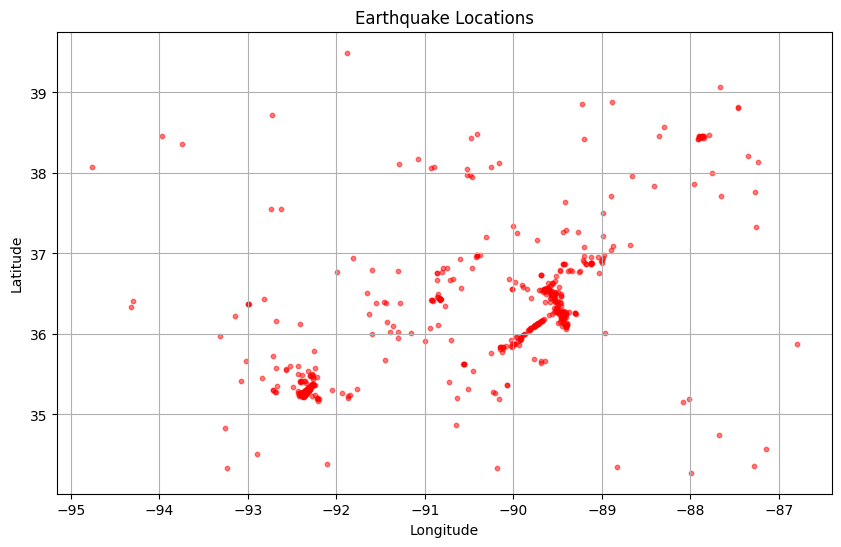

In [56]:
# Create a scatter plot with longitude and latitude
###
plt.figure(figsize=(10,6))
plt.scatter(df['longitude'], df['latitude'], c='red', alpha=0.5, s=10)
plt.title('Earthquake Locations')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()
# plt.scatter()
###

Earthquakes are distributed such that there are usually around 10x fewer earthquakes at each larger magnitude. I.e. there are 10x as many Mw 4's as 5's, etc. See if your earthquake catalog matches this!

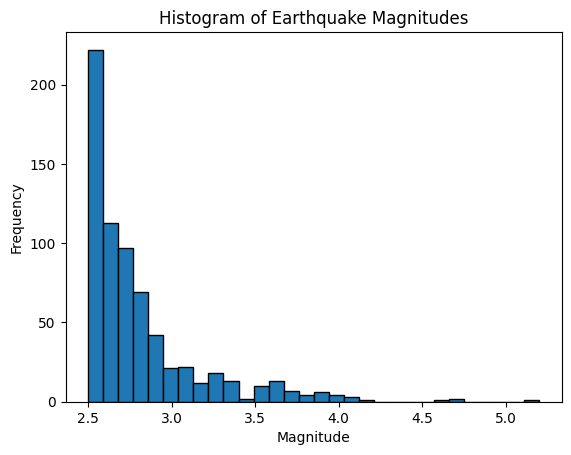

In [57]:
# Create a histogram of earthquake magnitudes
###
plt.hist(df['mag'].dropna(), bins=30, edgecolor='black')
plt.title('Histogram of Earthquake Magnitudes')
plt.xlabel('Magnitude')
plt.ylabel('Frequency')
plt.show()
# plt.hist()
###

Earthquake magnitudes in tectonically-active areas such as California tend to occur in distinct patterns - a somewhat random pattern of large events followed by clustered smaller events. Exam whether this trend is present in the dataset by plotting earthquake magnitudes through time.

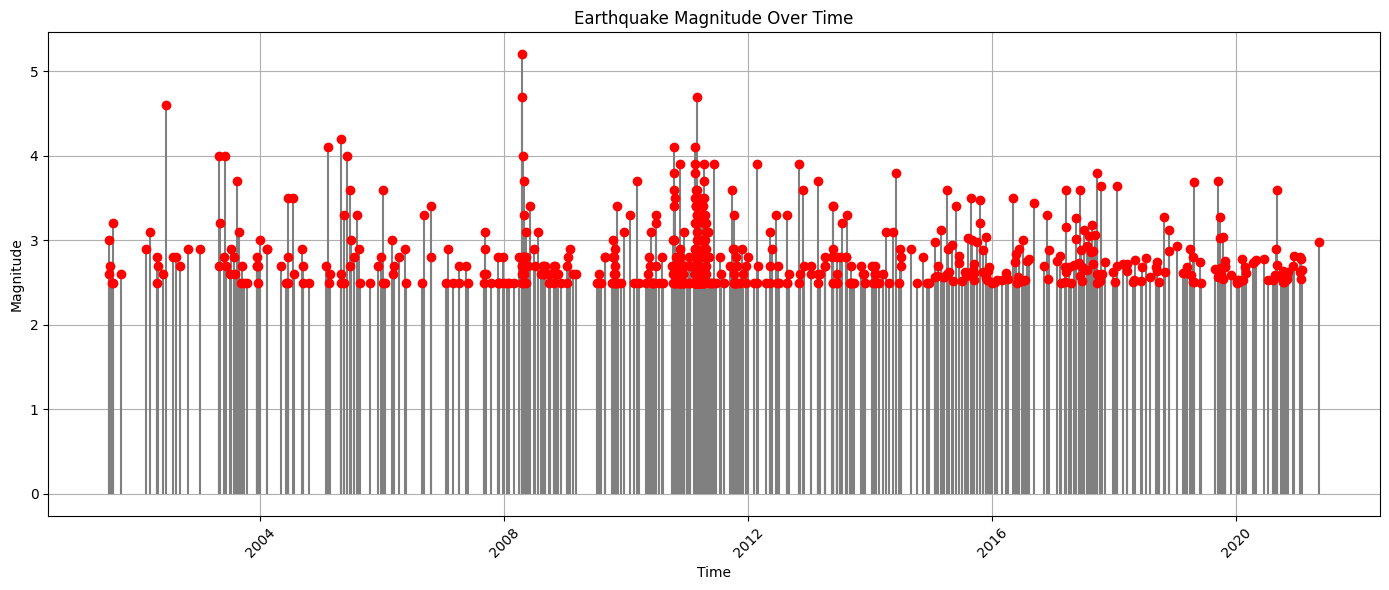

In [58]:
# Create a time-series plot of earthquake magnitude through time using a "stem" plot
###
# Convert time to datetime format
df['time'] = pd.to_datetime(df['time'])

# Drop rows with missing magnitude or time values
df = df.dropna(subset=['time', 'mag'])

# Optional: sort by time (to ensure correct time order)
df = df.sort_values('time')

# Create the stem plot
plt.figure(figsize=(14, 6))
(markerline, stemlines, baseline) = plt.stem(df['time'], df['mag'], linefmt='gray', markerfmt='ro', basefmt=" ")

plt.title('Earthquake Magnitude Over Time')
plt.xlabel('Time')
plt.ylabel('Magnitude')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()
# plt.stem()
###

Often it is helpful to look at a basic summary of your data using statistics. Compute and display the mean and quantiles of earthquake magnitude and the bounds on lat/lon coordinates and time, for the dataset. Calculate any other quantities you think may be of interest. You can import the Python library "numpy" for many different math functions.

In [59]:
# Numpy is a useful library for lots of math functionality
import numpy as np

In [60]:
# Basic statistics for the earthquake catalog
###
Mw_mean = df['mag'].mean()
Mw_q10 = df['mag'].quantile(0.10)
Mw_q25 = df['mag'].quantile(0.25)
Mw_q50 = df['mag'].quantile(0.50)  # This is the median
Mw_q75 = df['mag'].quantile(0.75)
Mw_q90 = df['mag'].quantile(0.90)
###
print("Mean magnitude is {:.2f}".format(Mw_mean))
print("The 10 and 90% Mw quantiles are {:.2f} and {:.2f}".format(Mw_q10, Mw_q90))
print("The 25 and 75% quantiles are {:.2f} and {:.2f}".format(Mw_q25, Mw_q75))
print("Median magnitude is {:.2f}".format(Mw_q50))

Mean magnitude is 2.79
The 10 and 90% Mw quantiles are 2.50 and 3.30
The 25 and 75% quantiles are 2.50 and 2.90
Median magnitude is 2.69


Finally, look at total moment through time. To do this, you'll need to write a function that converts magnitude (Mw) to moment (Mo). The equation for this is $$ Mo = 10^{1.5(Mw + 6.03)}$$ **Note**: moment has units of Newton-meters. Once you've calculuated moment for every earthquake, calculate and display the total moment for all earthquakes. Plot both instantaneous and cumulative earthquake moment through time. Finally, calculate the total moment of just the largest 5 earthquakes and calculate and print what percentage of the total moment those five largest events capture.

In [72]:
# First, write a function that converts a single moment magnitude to moment
def mw2mo(mw):
    '''Convert a single moment magnitude to moment'''
    ###
    mo = mo = 10 ** (1.5 * (mw + 6.03)) # you fill in the correct math here
    ###
    return mo

In [73]:
# Next write a function that loops through a set of magnitudes and calls mw2mo on each one.
def all_mws_to_mo(mw_list):
    '''Convert a list of moment magnitudes to moment'''
    mo_list = []
    ###
    for mw in mw_list:
        mo = mw2mo(mw)
        mo_list.append(mo)
    ###
    return mo_list

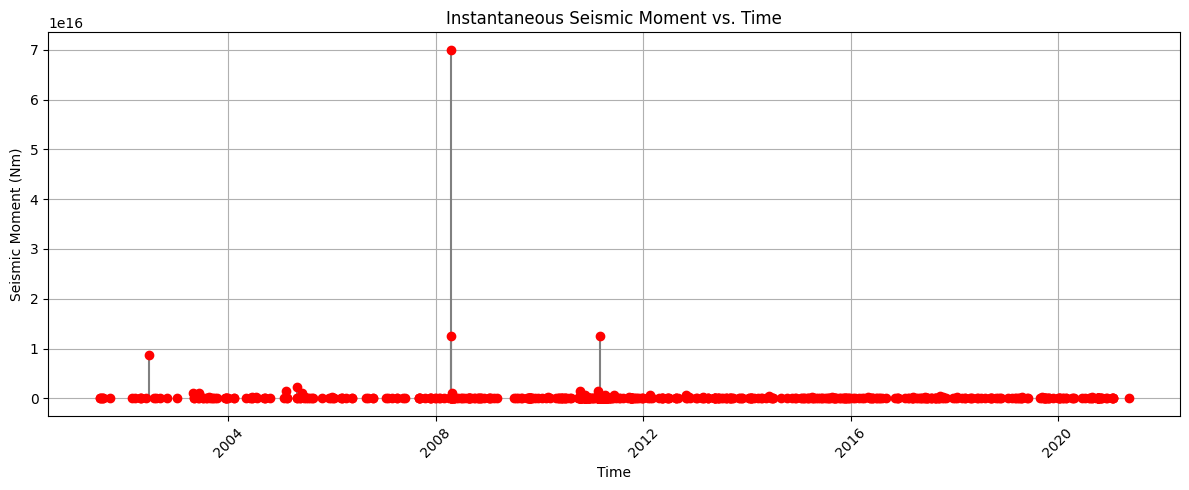

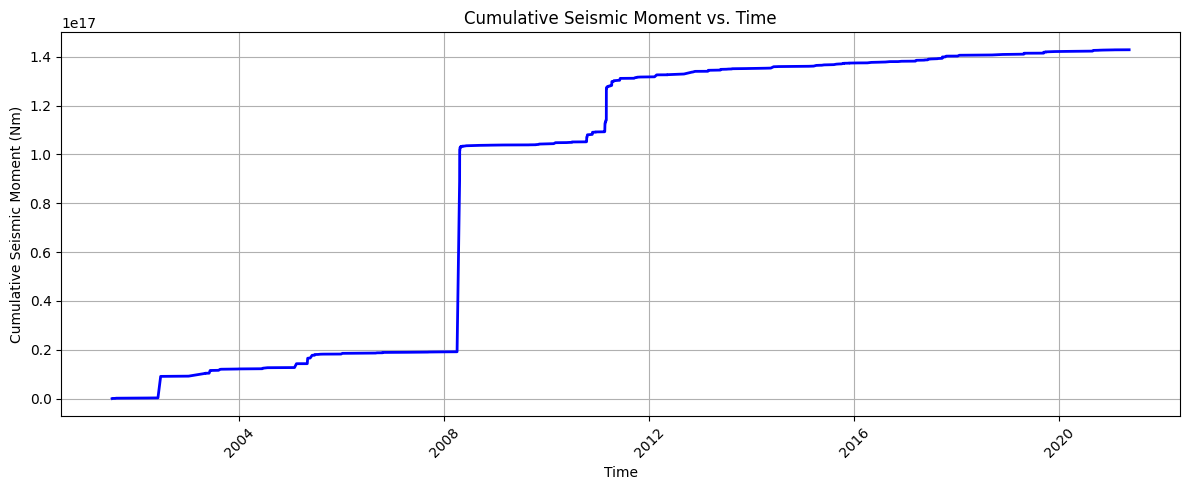

🔹 Total seismic moment (Nm): 1.428e+17
🔹 Seismic moment from top 5 largest events (Nm): 1.059e+17
🔹 Percentage of total moment from top 5 events: 74.13%


In [74]:
# Drop NaNs
df = df.dropna(subset=['mag', 'time'])

# Step 1: Calculate seismic moment for each earthquake
def mw2mo(mw):
    return 10 ** (1.5 * (mw + 6.03))

df['moment'] = df['mag'].apply(mw2mo)

# Step 2: Sort by time for plotting
df = df.sort_values('time')

# Step 3: Plot instantaneous moment vs. time
plt.figure(figsize=(12, 5))
plt.stem(df['time'], df['moment'], basefmt=" ", markerfmt="ro", linefmt='grey')
plt.title('Instantaneous Seismic Moment vs. Time')
plt.xlabel('Time')
plt.ylabel('Seismic Moment (Nm)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()

# Step 4: Plot cumulative moment over time
df['cumulative_mo'] = df['moment'].cumsum()

plt.figure(figsize=(12, 5))
plt.plot(df['time'], df['cumulative_mo'], color='blue', linewidth=2)
plt.title('Cumulative Seismic Moment vs. Time')
plt.xlabel('Time')
plt.ylabel('Cumulative Seismic Moment (Nm)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()

# Step 5: Total moment & top 5 event contribution
total_mo = df['moment'].sum()
top5_mo = df.nlargest(5, 'moment')['moment'].sum()
percentage = (top5_mo / total_mo) * 100

print(f"🔹 Total seismic moment (Nm): {total_mo:.3e}")
print(f"🔹 Seismic moment from top 5 largest events (Nm): {top5_mo:.3e}")
print(f"🔹 Percentage of total moment from top 5 events: {percentage:.2f}%")


### Tests
These tests will help you make sure to get your functions correct

In [64]:
print(mw2mo(5)) # This should print 3.5075... x 10^16

3.507518739525694e+16


In [65]:
print(mw2mo(1)) # This should print 35075187395.2568

35075187395.2568


In [66]:
print(all_mws_to_mo([1, 2, 3, 4, 5, 6, 7]))
'''
This should print a list that looks something like:
[35075187395.2568,
 1109174815262.4055,
 35075187395256.938,
 1109174815262405.4,
 3.507518739525694e+16,
 1.1091748152624054e+18,
 3.507518739525694e+19]
'''

[35075187395.2568, 1109174815262.4055, 35075187395256.938, 1109174815262405.4, 3.507518739525694e+16, 1.1091748152624054e+18, 3.507518739525694e+19]


'\nThis should print a list that looks something like: \n[35075187395.2568,\n 1109174815262.4055,\n 35075187395256.938,\n 1109174815262405.4,\n 3.507518739525694e+16,\n 1.1091748152624054e+18,\n 3.507518739525694e+19]\n'

Notice how moment grows by more than a factor of ten with each step in magnitude!

Now calculate moment for each earthquake in your database

In [75]:
# Calculate total moment
###
df['time'] = pd.to_datetime(df['time'], errors='coerce')  # Coerce invalid dates
df = df.dropna(subset=['mag', 'time'])
# Step 2: Calculate seismic moment (Mo) for each earthquake
def mw2mo(mw):
    return 10 ** (1.5 * (mw + 6.03))
df['Mo'] = df['mag'].apply(mw2mo)  # <--- Calculated moment
# Step 3: Sort by time
df = df.sort_values('time')
###

In [76]:
import numpy as np

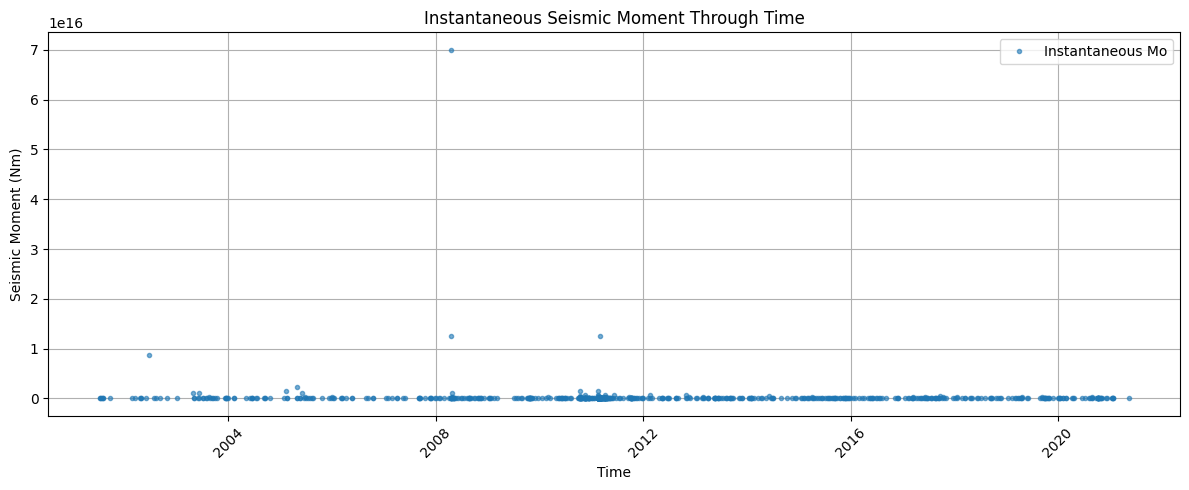

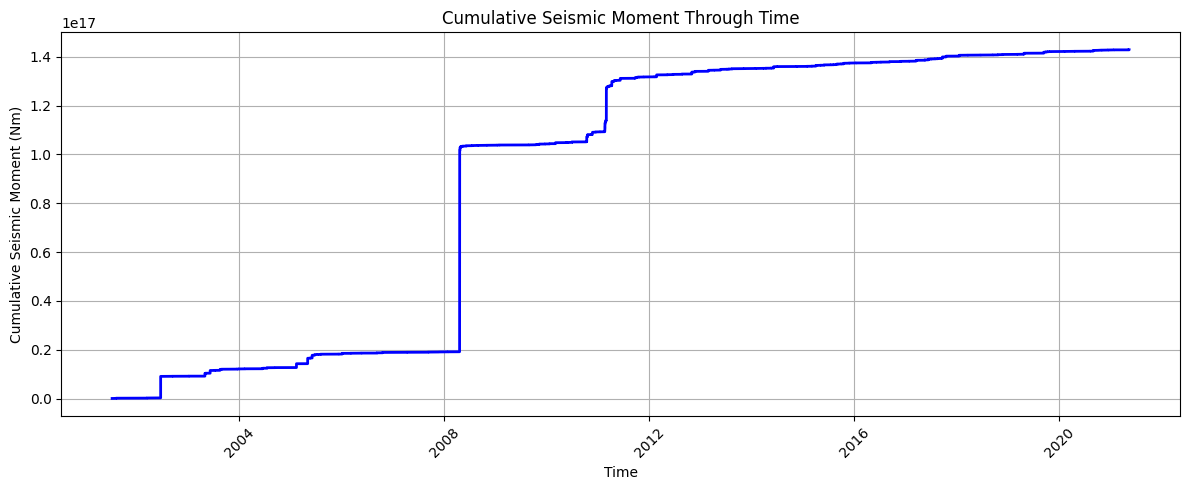

In [77]:
# Plot moment through time, both instantaneous and cumulative
###
# Step 4: Plot instantaneous and cumulative moment
plt.figure(figsize=(12, 5))

# Instantaneous moment (scatter or stem alternative)
plt.plot(df['time'], df['Mo'], '.', alpha=0.6, label='Instantaneous Mo')
plt.xlabel('Time')
plt.ylabel('Seismic Moment (Nm)')
plt.title('Instantaneous Seismic Moment Through Time')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

# Cumulative moment
plt.figure(figsize=(12, 5))
plt.step(df['time'], np.cumsum(df['Mo']), where='post', color='blue', linewidth=2)
plt.xlabel('Time')
plt.ylabel('Cumulative Seismic Moment (Nm)')
plt.title('Cumulative Seismic Moment Through Time')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# plt.plot()
# plt.step(t, np.cumsum())
###

In [70]:
# Calculate the percentage of moment released by the 5 largest events
num_largest = 5
###
# # Step 5: Percent of moment from top 5 earthquakes
num_largest = 5

# ✅ Fill in the code to compute the percentage
total_mo = df['Mo'].sum()
largest_mo_sum = df.nlargest(num_largest, 'Mo')['Mo'].sum()
percent_largest = (largest_mo_sum / total_mo) * 100

print(f"Percentage of total moment released by the {num_largest} largest events: {percent_largest:.2f}%")
###
print(percent_largest)

Percentage of total moment released by the 5 largest events: 74.13%
74.13354163289011


In [78]:
print()